<a href="https://colab.research.google.com/github/anix07/Stock-Price-Data-3921/blob/main/Stock_Price_Data_3921.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Stock_Price_Data_(3921) (1).csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Missing values per column:')
print(df.isnull().sum())
df.describe()

Shape: (9909, 7)
Date range: 1980-12-12 to 2020-04-01
Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume
count,9909,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,2000-07-30 08:33:08.010899200,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
min,1980-12-12 00:00:00,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1990-10-02 00:00:00,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,2000-07-21 00:00:00,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,2010-05-28 00:00:00,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,2020-04-01 00:00:00,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09
std,NaN,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07


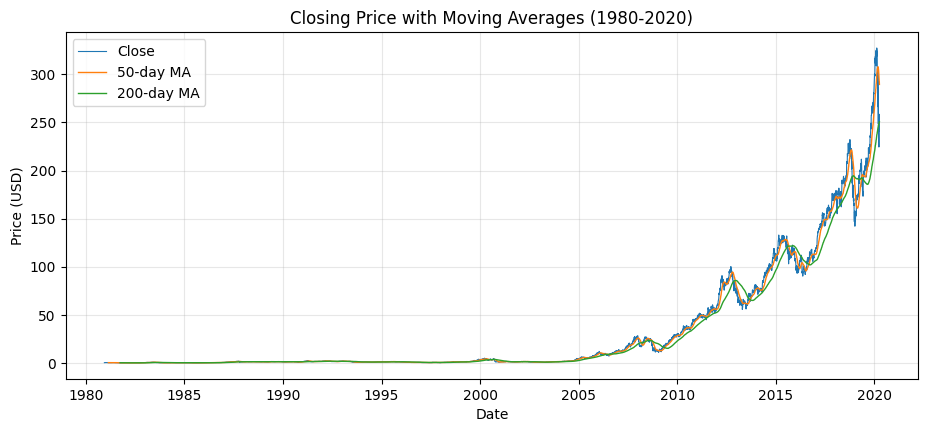

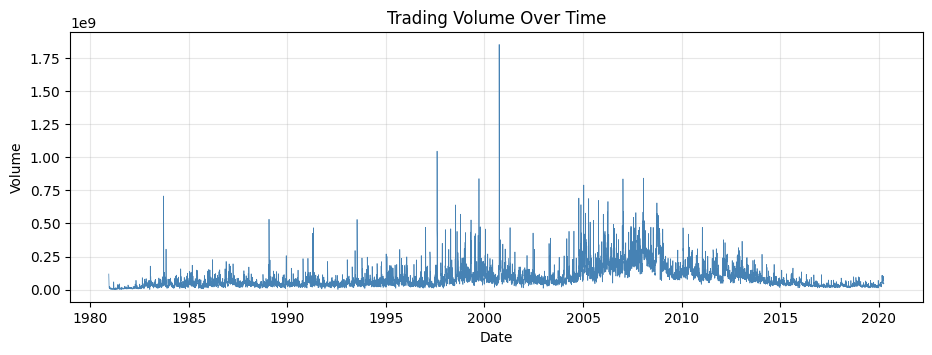

In [2]:
import matplotlib.pyplot as plt

df['MA50']  = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(11, 4.5))
plt.plot(df['Date'], df['Close'],  lw=0.8, label='Close')
plt.plot(df['Date'], df['MA50'],   lw=1.0, label='50-day MA')
plt.plot(df['Date'], df['MA200'],  lw=1.0, label='200-day MA')
plt.title('Closing Price with Moving Averages (1980-2020)')
plt.xlabel('Date'); plt.ylabel('Price (USD)'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(11, 3.5))
plt.plot(df['Date'], df['Volume'], lw=0.5, color='steelblue')
plt.title('Trading Volume Over Time')
plt.xlabel('Date'); plt.ylabel('Volume'); plt.grid(alpha=0.3); plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: restrict modelling window
df_model = df[df['Date'] >= '2010-01-01'].reset_index(drop=True)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df_model[features].values.astype('float32')

# Step 2: chronological split — 70% train, 15% validation, 15% test
n = len(data)
i_train, i_val = int(n * 0.70), int(n * 0.85)
train_raw = data[:i_train]
val_raw   = data[i_train:i_val]
test_raw  = data[i_val:]

# Step 3: scale — fit on training data only, to prevent leakage
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(train_raw)
scaler_y.fit(train_raw[:, 3:4])   # column 3 = Close

train_s = scaler_X.transform(train_raw)
val_s   = scaler_X.transform(val_raw)
test_s  = scaler_X.transform(test_raw)

In [4]:
def make_sequences(arr_scaled, seq_len):
    """Build sliding windows: input = past seq_len days, target = next day's Close."""
    X, y = [], []
    for i in range(seq_len, len(arr_scaled)):
        X.append(arr_scaled[i - seq_len:i])
        y.append(arr_scaled[i, 3])   # column 3 = Close
    return np.array(X), np.array(y)

def make_split_sequences(seq_len):
    """Build sequences for train/val/test. The tail of the previous split is
       prepended so the first seq_len predictions in each split aren't lost."""
    train_X, train_y = make_sequences(train_s, seq_len)
    val_arr  = np.vstack([train_s[-seq_len:], val_s])
    test_arr = np.vstack([val_s[-seq_len:], test_s])
    val_X,  val_y  = make_sequences(val_arr,  seq_len)
    test_X, test_y = make_sequences(test_arr, seq_len)
    return train_X, train_y, val_X, val_y, test_X, test_y

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dropout, Dense, Input

def build_lstm(seq_len, n_features, units=50, dropout=0.2, n_layers=2):
    m = Sequential([Input(shape=(seq_len, n_features))])
    for k in range(n_layers):
        m.add(LSTM(units, return_sequences=(k < n_layers - 1)))
        m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

In [6]:
def build_gru(seq_len, n_features, units=50, dropout=0.2, n_layers=2):
    m = Sequential([Input(shape=(seq_len, n_features))])
    for k in range(n_layers):
        m.add(GRU(units, return_sequences=(k < n_layers - 1)))
        m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import random

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

def inv_close(y_scaled):
    return scaler_y.inverse_transform(np.array(y_scaled).reshape(-1, 1)).flatten()

def evaluate(y_true_s, y_pred_s):
    y_true = inv_close(y_true_s)
    y_pred = inv_close(y_pred_s)
    return {
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        'R2':   float(r2_score(y_true, y_pred)),
    }, y_true, y_pred

experiments = [
    ('LSTM 1', 'lstm', 30, 50, 0.2),
    ('LSTM 2', 'lstm', 60, 64, 0.3),
    ('GRU 1',  'gru',  30, 50, 0.2),
    ('GRU 2',  'gru',  60, 64, 0.3),
]

results, histories, preds_store = {}, {}, {}

for name, kind, seq_len, units, dropout in experiments:
    tr_X, tr_y, va_X, va_y, te_X, te_y = make_split_sequences(seq_len)
    builder = build_lstm if kind == 'lstm' else build_gru
    model = builder(seq_len, tr_X.shape[2], units=units, dropout=dropout)

    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    hist = model.fit(tr_X, tr_y, validation_data=(va_X, va_y),
                     epochs=40, batch_size=128, callbacks=[es], verbose=0)

    pred = model.predict(te_X, verbose=0).flatten()
    metrics, y_true, y_pred = evaluate(te_y, pred)
    results[name] = {'seq_len': seq_len, 'units': units, 'dropout': dropout,
                     'epochs_trained': len(hist.history['loss']), **metrics}
    histories[name] = hist.history
    preds_store[name] = {'y_true': y_true, 'y_pred': y_pred}

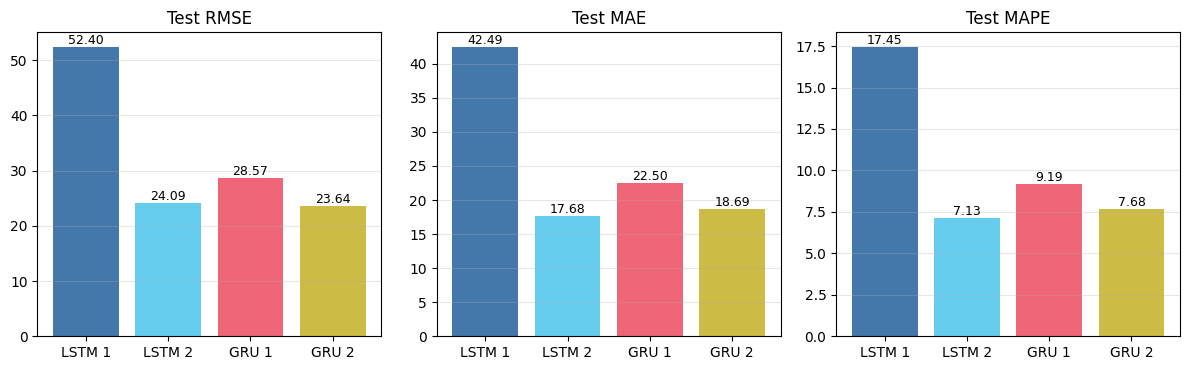

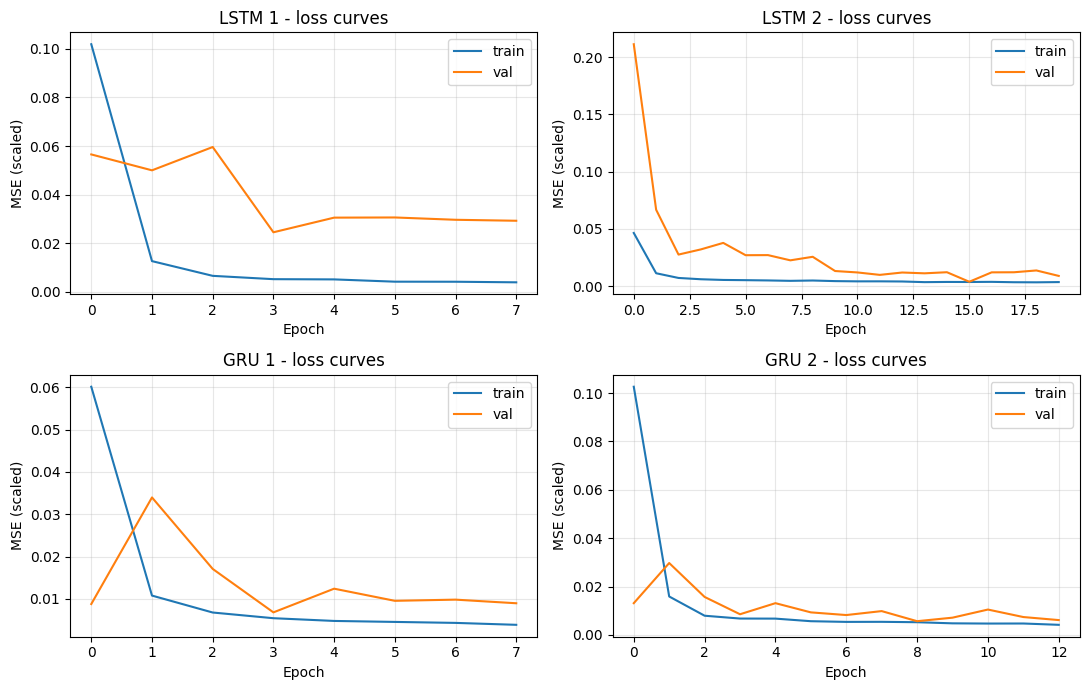

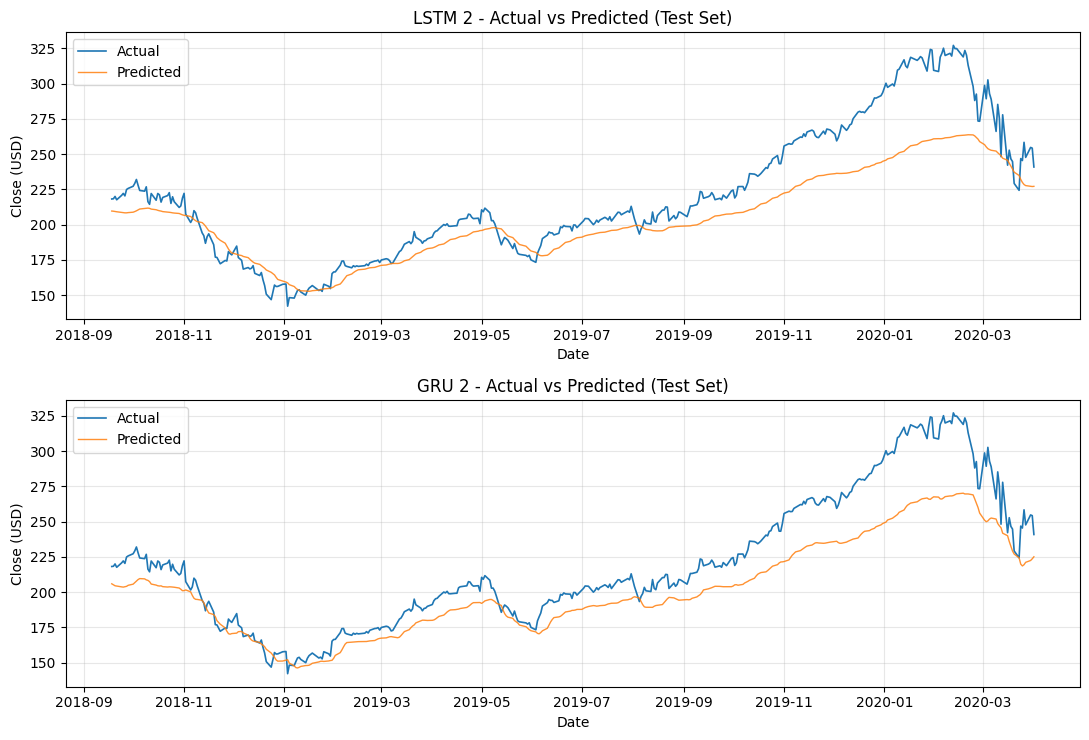

In [8]:
# Bar chart: comparison across metrics
labels = list(results.keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, m in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    vals = [results[k][m] for k in labels]
    bars = ax.bar(labels, vals, color=['#4477AA', '#66CCEE', '#EE6677', '#CCBB44'])
    ax.set_title(f'Test {m}'); ax.grid(alpha=0.3, axis='y')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

# Loss curves for each model
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, _, _, _, _) in zip(axes.flatten(), experiments):
    h = histories[name]
    ax.plot(h['loss'], label='train'); ax.plot(h['val_loss'], label='val')
    ax.set_title(f'{name} - loss curves'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
plt.tight_layout(); plt.show()

# Predicted vs actual for the best LSTM and best GRU
best_lstm = min(['LSTM 1', 'LSTM 2'], key=lambda n: results[n]['RMSE'])
best_gru  = min(['GRU 1',  'GRU 2'],  key=lambda n: results[n]['RMSE'])
test_dates = df_model['Date'].iloc[i_val:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5))
for ax, name in zip(axes, [best_lstm, best_gru]):
    p = preds_store[name]
    ax.plot(test_dates[:len(p['y_true'])], p['y_true'], label='Actual', lw=1.2)
    ax.plot(test_dates[:len(p['y_pred'])], p['y_pred'], label='Predicted', lw=1.0, alpha=0.85)
    ax.set_title(f'{name} - Actual vs Predicted (Test Set)')
    ax.set_xlabel('Date'); ax.set_ylabel('Close (USD)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()